In [1]:
import xgboost as xgb
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geoplot as gplt
import geoplot.crs as gcrs
from sklearn.model_selection import train_test_split
import contextily as cx

In [2]:
data = pd.read_csv('../data/seattle_sample_3k.csv')

In [3]:
data = gpd.GeoDataFrame(data, crs="EPSG:32610", geometry=gpd.points_from_xy(x=data.UTM_X, y=data.UTM_Y))

In [4]:
data = data.to_crs(4326)

In [5]:
data['lat'] = data['geometry'].get_coordinates()['x']
data['lon'] = data['geometry'].get_coordinates()['y']

In [6]:
data['price'] = np.power(10, data['log_price']) / 10000

In [7]:
y = data.price
X = data[['bathrooms', 'sqft_living', 'sqft_lot', 'grade', 'condition', 'waterfront', 'view', 'age', 'UTM_X', 'UTM_Y']]
loc = data[['lat','lon']]

In [8]:
X_train, X_temp, y_train, y_temp, loc_train, loc_temp = train_test_split(X, y, loc, train_size=0.8, random_state=42)

In [9]:
X_calib, X_test, y_calib, y_test, loc_calib, loc_test = train_test_split(X_temp, y_temp, loc_temp, train_size=0.5, random_state=42)


In [10]:
model = xgb.XGBRegressor(n_estimators=500, max_depth=3, min_child_weight=1.0, colsample_bytree=1.0)

In [11]:
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=1.0, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=1.0, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=500, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [12]:
model.score(X_test, y_test)

0.8705986887146308

In [13]:
from GeoConformal import GWQRBasedGeoConformalSpatialPrediction

In [14]:
geocp = GWQRBasedGeoConformalSpatialPrediction(predict_f=model.predict, nonconformity_score_f=None, miscoverage_level=0.1, alpha=8, coord_calib=loc_calib.values, coord_test=loc_test.values, x_calib=X_calib, y_calib=y_calib, x_test=X_test, y_test=y_test)

In [15]:
results = geocp.analyze()

100%|██████████| 300/300 [01:57<00:00,  2.55it/s]


In [16]:
results.coverage_probability

0.7

In [17]:
results.geo_uncertainty.mean() / 2

11.64448739500216

In [18]:
geo_results = results.to_gpd()

In [19]:
geo_results

,geo_uncertainty,pred,upper_bound,lower_bound,k,beta,alpha,x,y,geometry
0,42.897835,86.552925,103.713394,60.815559,186.0,0.036106,14.999945,-122.178,47.6948,POINT (-122.178 47.6948)
1,21.123135,26.823208,34.274075,13.150940,61.0,0.022170,12.237938,-122.364,47.5030,POINT (-122.364 47.503)
2,25.030271,45.883007,57.698922,32.668651,275.0,0.081449,3.520911,-122.360,47.5659,POINT (-122.36 47.5659)
3,17.898520,35.864384,45.312031,27.413511,211.0,0.065413,12.240020,-122.304,47.5880,POINT (-122.304 47.588)
4,26.671286,29.032578,39.282275,12.610989,178.0,0.004759,14.143983,-122.288,47.5412,POINT (-122.288 47.5412)
...,...,...,...,...,...,...,...,...,...,...
295,24.368177,47.090702,64.040188,39.672010,109.0,0.023670,14.999945,-122.127,47.6557,POINT (-122.127 47.6557)
296,4.000406,25.835550,30.722961,26.722555,15.0,0.032140,14.119278,-122.242,47.2630,POINT (-122.242 47.263)
297,26.038997,91.125793,107.189699,81.150701,72.0,0.051473,14.999945,-122.405,47.6420,POINT (-122.405 47.642)
298,15.242581,65.963219,71.490608,56.248027,10.0,0.076433,14.999945,-122.359,47.6797,POINT (-122.359 47.6797)


<GeoAxes: >

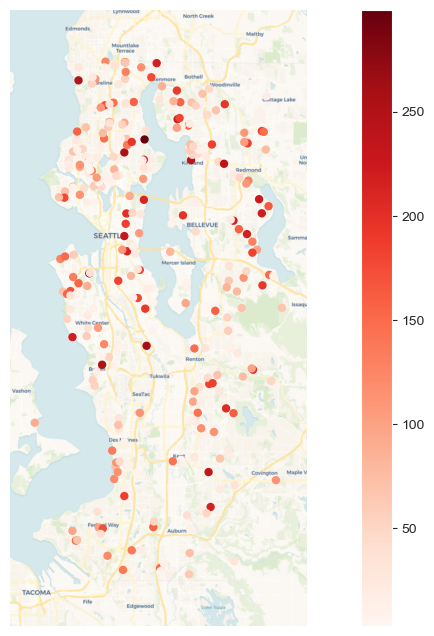

In [20]:
utm = gcrs.WebMercator()

ax = gplt.webmap(geo_results, projection=utm, figsize=(14, 8), provider=cx.providers.CartoDB.Voyager)

gplt.pointplot(geo_results, hue='k', cmap='Reds', legend=True, ax=ax)

In [21]:
from GeoConformal import GeoConformalSpatialPrediction

In [22]:
geocp_spatial_std = GeoConformalSpatialPrediction(predict_f=model.predict, nonconformity_score_f=None, miscoverage_level=0.1, bandwidth=0.15, coord_calib=loc_calib.values, coord_test=loc_test.values, X_calib=X_calib, y_calib=y_calib, X_test=X_test, y_test=y_test)

In [23]:
results_std = geocp_spatial_std.analyze()

In [24]:
results_std.coverage_probability

0.9366666666666666

In [25]:
results_std.geo_uncertainty.mean()

19.452105716929108